In [190]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skimage import util, exposure
from skimage.io import imread
from skimage.filters import  threshold_triangle, median, sobel, gaussian
from skimage.measure import label,  regionprops_table, regionprops,  moments_central
from skimage.morphology import  disk, remove_small_objects, binary_dilation, remove_small_holes , erosion, closing, skeletonize, binary_closing, disk, binary_opening
from skimage.transform import rotate
from scipy.ndimage import rotate, binary_dilation
from skimage.transform import probabilistic_hough_line
from skimage.draw import line
from skimage.filters import gaussian, threshold_otsu, threshold_sauvola, frangi, sato, threshold_yen, threshold_triangle, threshold_local, threshold_mean, threshold_li, threshold_minimum, try_all_threshold
from skimage import util
from liffile import LifFile
import napari
import warnings
warnings.filterwarnings("ignore")

from skimage.graph import route_through_array

import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import median
from skimage.filters import gaussian, threshold_otsu, sobel_v
from skimage import exposure
from skimage.morphology import binary_closing, disk, remove_small_objects, skeletonize, binary_dilation, binary_erosion
from skimage.measure import label, regionprops
from skimage.graph import route_through_array
from skimage.filters import sato
import numpy as np
from skimage.draw import line as sk_line


In [191]:
def vertical_brightness_ratio(img, eps=1e-6):
    """
    Measures brightness discontinuity top vs bottom.
    Returns absolute log ratio: abs(log(top/bottom)).
    """
    y = int(img.shape[0] * 0.5)
    a = np.median(img[:y])
    b = np.median(img[y:])
    return float(abs(np.log((a + eps) / (b + eps))))

In [ ]:
def fit_line(x, y):
    if x.size < 2:
        return 0.0, float(y[0]) if y.size else H / 2
    return np.polyfit(x.astype(float), y.astype(float), 1)

def extend_path_to_edges(path_mask, k=5, max_gap=30, edge_tol=0):
    """
    Extend a left-to-right path so it touches x=0 and x=W-1, but ONLY if the
    cur`arent path endpoints are within `max_gap` pixels of those edges.

    - If already touches both edges (within edge_tol), do nothing.
    - If too far from either edge (> max_gap), do not extend either side.
    """
    m = path_mask.astype(bool).copy()
    H, W = m.shape
    ys, xs = np.nonzero(m)

    if xs.size < 2:
        return m

    left_gap  = int(xs.min())          # distance to x=0
    right_gap = int((W - 1) - xs.max()) # distance to x=W-1

    # already spans (optionally with tolerance)
    if left_gap <= edge_tol and right_gap <= edge_tol:
        return m


    # ---- LEFT EXTENSION (only if close enough) ----
    elif left_gap <= max_gap:
        print("left extended")
        idx = np.argsort(xs)[:min(k, xs.size)]
        a, b = fit_line(xs[idx], ys[idx])
        x0 = int(xs[idx].min())
        y0 = int(np.clip(round(a * x0 + b), 0, H - 1))
        y_edge = int(np.clip(round(b), 0, H - 1))  # x=0
        rr, cc = sk_line(y_edge, 0, y0, x0)
        m[rr, cc] = True

        # ---- RIGHT EXTENSION (only if close enough AND OK on left too) ----
        if right_gap <= max_gap:
            print("left and right extended")
            idx = np.argsort(xs)[-min(k, xs.size):]
            a, b = fit_line(xs[idx], ys[idx])
            x1 = int(xs[idx].max())
            y1 = int(np.clip(round(a * x1 + b), 0, H - 1))
            y_edge = int(np.clip(round(a * (W - 1) + b), 0, H - 1))
            rr, cc = sk_line(y1, x1, y_edge, W - 1)
            m[rr, cc] = True

    return m

In [ ]:

def extract_boundary(img, thr_func, min_size=100, area_threshold=500, opening_size=3): 
    bw_orig = img > thr_func(img)
    bw = remove_small_objects(bw_orig, min_size=min_size)
    bw = remove_small_holes(bw, area_threshold=area_threshold)
    bw = binary_opening(bw, disk(opening_size))


    labels = label(bw)
    if labels.max() > 0:
        props = regionprops(labels)
        biggest = max(props, key=lambda p: p.area)
        bw = (labels == biggest.label)

    # interface line
    path_mask = bw ^ binary_erosion(bw, disk(1))
    lab = label(path_mask)
    if lab.max() > 0:
        props = regionprops(lab)
        longest = max(props, key=lambda p: p.area) # area == number of pixels
        path_mask = (lab == longest.label)
    return path_mask, bw


def find_best_left_right_route(mask, edge_margin=30, step_cost=100.0):
    H, W = mask.shape

    # Candidate endpoints in left/right margin bands
    left_band  = mask[:, :edge_margin]
    right_band = mask[:, W-edge_margin:]

    left_pts  = list(map(tuple, np.argwhere(left_band)))
    right_pts = list(map(tuple, np.argwhere(right_band)))
    right_pts = [(y, W-edge_margin + x) for (y, x) in right_pts]

    # If we didn't get endpoints (mask slightly short), do a tiny dilation and retry
    if (len(left_pts) == 0) or (len(right_pts) == 0):
        m2 = binary_dilation(mask, disk(2))
        left_band  = m2[:, :edge_margin]
        right_band = m2[:, W-edge_margin:]
        left_pts  = list(map(tuple, np.argwhere(left_band)))
        right_pts = list(map(tuple, np.argwhere(right_band)))
        right_pts = [(y, W-edge_margin + x) for (y, x) in right_pts]
    else:
        m2 = mask

    # Cost: prefer mask, penalize background (allows tiny gaps via m2 dilation)
    off_penalty = step_cost * 0.2 # try 0.05–0.5
    cost = np.where(m2, step_cost, step_cost + off_penalty).astype(np.float32)

    # Cheap reduction of endpoints to avoid O(N^2)
    max_candidates = 50
    if len(left_pts) > max_candidates:
        left_pts = [left_pts[i] for i in np.linspace(0, len(left_pts)-1, max_candidates).astype(int)]
    if len(right_pts) > max_candidates:
        right_pts = [right_pts[i] for i in np.linspace(0, len(right_pts)-1, max_candidates).astype(int)]

    best_score = np.inf
    best_path = None

    for s in left_pts:
        for t in right_pts:
            path, _c = route_through_array(cost, s, t, fully_connected=True)
            path_len = len(path)

            off_count = sum(not m2[y, x] for (y, x) in path)
            score = path_len + 200 * off_count  # heavier penalty to stay on m2

            if score < best_score:
                best_score = score
                best_path = path

    path_mask = np.zeros_like(mask, dtype=bool)
    if best_path is not None:
        for y, x in best_path:
            path_mask[y, x] = True
        return path_mask
    else:
        return None

In [206]:
def find_ridge_through_plane(img_slice, to_plot=True, ratio_cutoff=0.75):
    # # Gate: decide edge-mode vs ridge-mode
    vr = vertical_brightness_ratio(img_slice)
    mode = "edge" if vr > ratio_cutoff else "ridge"    
    if mode == "edge": 
        H, W = img_slice.shape
        # --- First attempt: Li ---
        img_med = median(img_slice, disk(7))
        path_mask, bw = extract_boundary(img_med, threshold_li)
        title = "li"
        
        # --- Sanity check: boundary too long? ---
        if path_mask.sum() > 1.5 * W:
            title = "minimum"
            path_mask, bw = extract_boundary(img_med, threshold_minimum, min_size = 0, area_threshold = 0, opening_size=0)
        elif path_mask[0, :].any() or path_mask[-1, :].any():
            title = "triangle"
            path_mask, bw = extract_boundary(exposure.adjust_gamma(img_med, gamma=0.2), threshold_triangle, min_size = 0, area_threshold = 0, opening_size=10)
            
        path_mask = extend_path_to_edges(path_mask,  k=5, max_gap=30, edge_tol=0)
                
    else: ####### ridge mode 
        title="ridge"
        img_med = median(img_slice, disk(7))
        resp = sato(img_med, sigmas=np.linspace(2, 8, 10), black_ridges=True)
        resp = exposure.rescale_intensity(resp)
        thr = threshold_yen(resp)
        bw = resp > thr
        bw = binary_closing(bw, footprint=disk(9))
        bw = remove_small_objects(bw, min_size=600)
        skel = skeletonize(bw)
        lab = label(skel)
        if lab.max() > 0:
            props = regionprops(lab)
            props_sorted = sorted(props, key=lambda p: p.area, reverse=True)
            labels_to_keep = [p.label for p in props_sorted[:3]]
            skel_main = np.isin(lab, labels_to_keep)
        else:
            skel_main = skel

        path_mask = find_best_left_right_route(skel_main)
        if path_mask is None:
            path_mask = find_best_left_right_route(skel)
        if path_mask is not None:
            path_mask = extend_path_to_edges(path_mask,  k=5, max_gap=30, edge_tol=0)

    if to_plot:
        fig, ax = plt.subplots(ncols=3, figsize=(6, 3))
        ax[0].imshow(img_slice, cmap="gray")
        ax[1].imshow(bw, cmap="gray")
        ax[2].imshow(img_slice, cmap="gray")
        ax[0].set_title("input")
        ax[1].set_title(title)
        ax[2].set_title("path")
        if path_mask is not None:
            y, x = np.nonzero(path_mask)
            ax[2].scatter(x, y, s=2, c="red")
        for a in ax:
            a.axis("off")
        plt.suptitle(f"Mode:{mode}, Brightness ratio:{vr}")
        plt.tight_layout()
        plt.show()
    print(f"Mode={mode}, threshold={title}")
    return path_mask, mode, vr

2
Opening image Exp6_20260122_Thalidomide-Ibuprofen.lif, which has dimensions ('T', 'C', 'Z', 'Y', 'X') and shape (4, 3, 41, 512, 512)
dextran_t0 shape: (41, 512, 512)


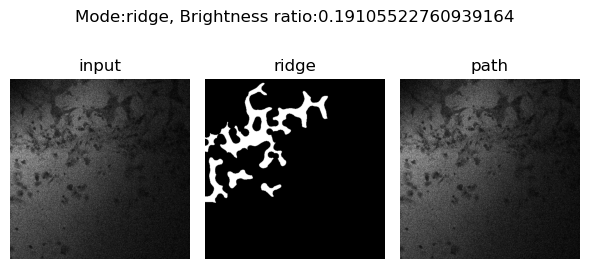

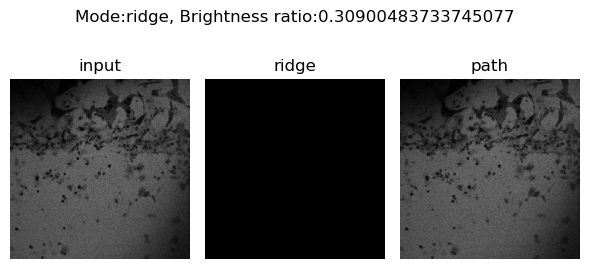

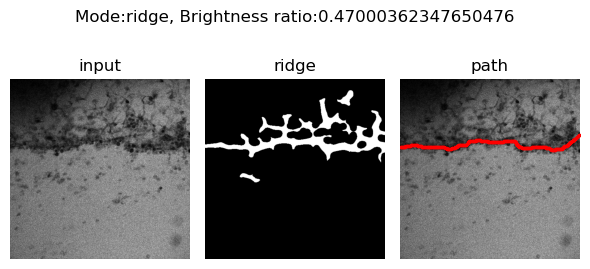

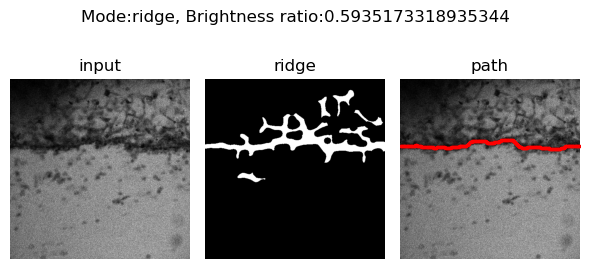

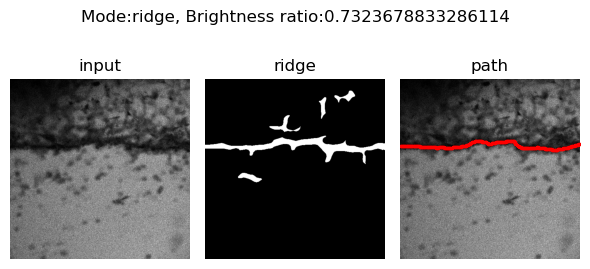

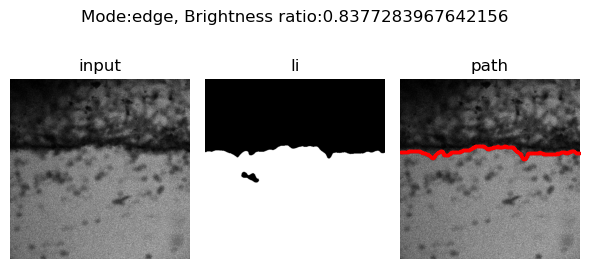

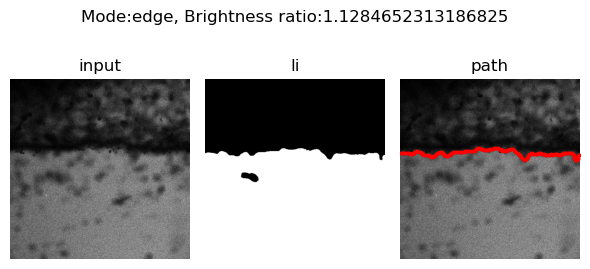

In [ ]:
folder = Path(r"Z:\Maria Cuende\0_Projects\0_Placenta\Barrier integrity\20260115-22_Exp6")
lif_files = list(folder.glob("*.lif"))
print(len(lif_files))

lif_path = lif_files[1]
image_index = 4

for image_index in [image_index]:
    dextran_channel = 2
    with LifFile(lif_path) as lif:
        img = lif.images[image_index]
        print(f"Opening image {lif.name}, which has dimensions {getattr(img, 'dims', None)} and shape {img.shape}")
        img = img.asarray()
    dextran_t0 = img[0, dextran_channel, :, :, :]
    print("dextran_t0 shape:", dextran_t0.shape)


    for z in [5,7,12,15,18,20,25]:
        path_mask, mode, vr = find_ridge_through_plane(dextran_t0[z, :, :], to_plot=True)

In [215]:
import numpy as np

# -----------------------------
# 1) Get all lines (per z)
# -----------------------------
def get_lines_over_z(vol_zyx, ratio_cutoff=0.75, z_indices=None, discard_top_bottom=True):
    """
    Returns:
      lines: dict[z] -> path_mask (bool) or None
      meta:  dict[z] -> {"mode":..., "vr":...} (for debugging)
      found_zs: sorted list of z where a valid line was found
    """
    Z, H, W = vol_zyx.shape
    if z_indices is None:
        z_indices = range(Z)

    lines = {}
    meta = {}
    found_zs = []

    for z in z_indices:
        pm, mode, vr = find_ridge_through_plane(vol_zyx[z], to_plot=False, ratio_cutoff=ratio_cutoff)
        meta[z] = {"mode": mode, "vr": vr}

        if pm is None or pm.sum() == 0:
            lines[z] = None
            continue

        pm = pm.astype(bool)

        if discard_top_bottom and (pm[0, :].any() or pm[-1, :].any()):
            lines[z] = None
            continue

        lines[z] = pm
        found_zs.append(z)

    found_zs = sorted(found_zs)
    return lines, meta, found_zs


# helpers: profile + gap fill
def _pathmask_to_profile_y(pm):
    """y(x) over x=0..W-1 via interpolation."""
    H, W = pm.shape
    y, x = np.nonzero(pm)
    if y.size < 2:
        return None
    order = np.argsort(x)
    x = x[order].astype(float)
    y = y[order].astype(float)
    x_u, idx = np.unique(x, return_index=True)
    y_u = y[idx]
    if x_u.size < 2:
        return None
    x_grid = np.arange(W, dtype=float)
    return np.interp(x_grid, x_u, y_u, left=y_u[0], right=y_u[-1])

def _interp_missing_slice(pm_a, pm_b):
    """Interpolate line between two masks (assumes same H,W)."""
    H, W = pm_a.shape
    ya = _pathmask_to_profile_y(pm_a)
    yb = _pathmask_to_profile_y(pm_b)
    if ya is None or yb is None:
        return None
    ymid = 0.5 * (ya + yb)
    out = np.zeros((H, W), dtype=bool)
    xs = np.arange(W)
    ys = np.clip(np.round(ymid).astype(int), 0, H - 1)
    out[ys, xs] = True
    return out


# -------------------------------------------------------------
# 2) Keep "bottom stable" block; drop unstable upper lines
# -------------------------------------------------------------
def keep_stable_bottom_block(
    lines,
    allow_single_slice_gap=True,
    delta_thresh_px=None,
    consec_bad=2,
    top_margin=0,
    debug=False,
):
    """
    lines: dict[z]->bool mask or None

    Keeps everything from the first available z up to a cutoff where line changes become unstable.
    Optionally fills single-slice gaps inside the active range.

    Returns:
      kept_lines: dict[z]->bool mask (includes filled single-gap slices)
      kept_zs: sorted list of z kept
      found_zs: sorted list of z where a line was originally found (non-None in input)
    """
    zs = sorted(lines.keys())
    found_zs = [z for z in zs if lines[z] is not None]
    if len(found_zs) == 0:
        return {}, [], []

    z_start, z_end = found_zs[0], found_zs[-1]

    # copy so we can fill gaps
    work = {z: (None if lines[z] is None else lines[z].copy()) for z in zs}

    # fill single-slice gaps (only between existing neighbors)
    if allow_single_slice_gap:
        for z in range(z_start + 1, z_end):
            if work.get(z) is None and work.get(z - 1) is not None and work.get(z + 1) is not None:
                pm = _interp_missing_slice(work[z - 1], work[z + 1])
                if pm is not None:
                    work[z] = pm
                    if debug:
                        print(f"Filled gap at z={z}")

    # build profiles where available
    yprof = {}
    for z in range(z_start, z_end + 1):
        if work.get(z) is None:
            continue
        yprof[z] = _pathmask_to_profile_y(work[z])

    # deltas across consecutive z (where both exist)
    deltas = {}
    for z in range(z_start + 1, z_end + 1):
        if yprof.get(z) is None or yprof.get(z - 1) is None:
            continue
        deltas[z] = float(np.median(np.abs(yprof[z] - yprof[z - 1])))

    vals = np.array(list(deltas.values()), dtype=float)

    if vals.size == 0:
        z_keep_max = z_end
    else:
        if delta_thresh_px is None:
            # auto threshold: typical + half the tail spread
            q50 = np.quantile(vals, 0.50)
            q90 = np.quantile(vals, 0.90)
            delta_thresh_px = q50 + 0.5 * (q90 - q50)

        bad_run = 0
        z_keep_max = z_end
        for z in range(z_start + 1, z_end + 1):
            if z not in deltas:
                continue
            bad_run = bad_run + 1 if (deltas[z] > delta_thresh_px) else 0
            if bad_run >= consec_bad:
                z_cut = z - consec_bad
                z_keep_max = min(z_end, z_cut + top_margin)
                break

    kept_zs = [z for z in range(z_start, z_keep_max + 1) if work.get(z) is not None]
    kept_lines = {z: work[z] for z in kept_zs}

    if debug:
        print("found_zs:", found_zs[:12], "..." if len(found_zs) > 12 else "")
        print("kept_zs:", kept_zs[:12], "..." if len(kept_zs) > 12 else "")
        if vals.size:
            print(f"delta_thresh_px={delta_thresh_px:.2f}, consec_bad={consec_bad}, top_margin={top_margin}")

    return kept_lines, kept_zs, found_zs


# -------------------------------------------------------------------
# 3) Convert kept lines to a 2D plane mask + return cross-section area
# -------------------------------------------------------------------
def lines_to_plane_and_area(kept_lines, shape_hw, side="below", z_agg="union"):
    """
    kept_lines: dict[z]->bool path mask (2D)
    shape_hw: (H,W)
    side: "below" or "above" relative to barrier y(x)
    z_agg:
      - "union": plane_mask = OR over z of filled regions
      - "median": plane_mask from median y(x) across z (good if barrier stable)

    Returns:
      plane_mask_hw (bool)
      areas_by_z (dict[z]->int): filled area per slice (pixels)
      z_used (sorted list of z in kept_lines)
    """
    H, W = shape_hw
    z_used = sorted(kept_lines.keys())
    if len(z_used) == 0:
        return np.zeros((H, W), bool), {}, []

    # per-z filled regions and per-z areas
    filled_by_z = {}
    areas_by_z = {}
    y_profiles = []

    for z in z_used:
        pm = kept_lines[z]
        yx = _pathmask_to_profile_y(pm)
        if yx is None:
            continue
        yy = np.clip(np.round(yx).astype(int), 0, H - 1)

        Y = np.arange(H)[:, None]
        YY = yy[None, :]
        if side == "below":
            filled = (Y >= YY)
        elif side == "above":
            filled = (Y <= YY)
        else:
            raise ValueError("side must be 'below' or 'above'")

        filled_by_z[z] = filled
        areas_by_z[z] = int(filled.sum())
        y_profiles.append(yx)

    if len(filled_by_z) == 0:
        return np.zeros((H, W), bool), {}, []

    if z_agg == "union":
        plane = np.zeros((H, W), dtype=bool)
        for z in filled_by_z:
            plane |= filled_by_z[z]
    elif z_agg == "median":
        # build a single representative plane using median y(x) across z
        YX = np.stack(y_profiles, axis=0)          # (nZ, W)
        y_med = np.median(YX, axis=0)
        yy = np.clip(np.round(y_med).astype(int), 0, H - 1)
        Y = np.arange(H)[:, None]
        YY = yy[None, :]
        plane = (Y >= YY) if side == "below" else (Y <= YY)
    else:
        raise ValueError("z_agg must be 'union' or 'median'")

    return plane, areas_by_z, sorted(filled_by_z.keys())

In [216]:
lines, meta, found_zs = get_lines_over_z(dextran_t0, ratio_cutoff=0.75)


Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=ridge, threshold=ridge
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=li
Mode=edge, threshold=minimum
Mode=edge, threshold=minimum
Mo

In [217]:


# 2) keep bottom stable block (cut off unstable upper region)
kept_lines, kept_zs, found_zs = keep_stable_bottom_block(
lines,
allow_single_slice_gap=True,
delta_thresh_px=None, # auto
consec_bad=2,
top_margin=0,
debug=True
)


found_zs: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22] ...
kept_zs: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22] ...
delta_thresh_px=3.00, consec_bad=2, top_margin=0


In [218]:


# 3) convert kept lines to a single 2D plane + per-z cross-sectional areas
H, W = dextran_t0.shape[1:]
plane_hw, areas_by_z, z_used = lines_to_plane_and_area(
kept_lines,
(H, W),
side="below", # or "above"
z_agg="median" # "median" is usually what you want if the barrier is stable
)


print("found_zs:", found_zs)
print("kept_zs:", kept_zs)
print("areas (first 10):", [(z, areas_by_z[z]) for z in z_used[:10]])

found_zs: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
kept_zs: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
areas (first 10): [(11, 166299), (12, 166237), (13, 166163), (14, 165897), (15, 165595), (16, 165456), (17, 165138), (18, 164913), (19, 157335), (20, 156987)]


In [221]:
viewer = napari.Viewer()
viewer.add_labels(plane_hw)
viewer.add_image(dextran_t0)


<Image layer 'dextran_t0' at 0x15ed63f4610>